# Matplotlib

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Since `matplotlib` is primarily a graphing library rather than a conventional object-oriented toolkit, it can be more helpful to understand matplotlib in terms of how it builds a plot instead of beginning with classes like `Figure`, `Axes`, or `Artist`:

- At the top level, you have the **figure** — the canvas or overall container for your plot.
- Inside a figure, you can place one or more **axes** (one axes: x axis and y axis), which represent individual coordinate systems.
- Within each axes, you add **graphical elements** — lines, bars, text, ticks, etc.
- Render the plot: `plt.show()`
- Save the plot: `plt.savefig()`

## I. Figure and Axes

A figure (class `Figure`) can be created by `plt.figure()`. However, by itself, a figure is just an empty canvas. To display any meaningful content, you need to add at least one axes (class `Axes`) — without it, nothing will be visible on the plot.

In [2]:
fig = plt.figure() # empty figure
print(type(fig))
plt.show()

<class 'matplotlib.figure.Figure'>


<Figure size 640x480 with 0 Axes>

<class 'matplotlib.figure.Figure'> <class 'matplotlib.axes._axes.Axes'>


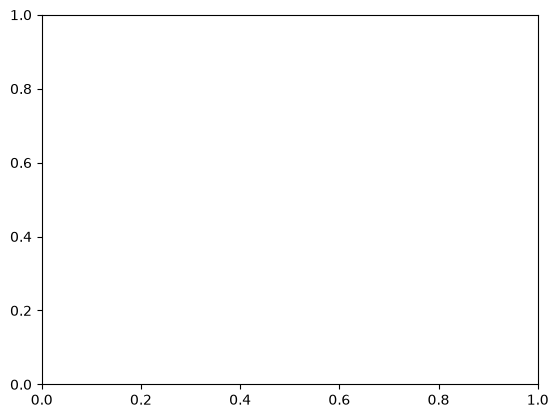

In [3]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1) # equivalent to fig.add_subplot(111)
print(type(fig), type(ax))
plt.show() # In Jupyter notebook, plt.show() is optional. However, in scripts (.py), it is necessary to display the figure.

Why is it called subplot? Because we can add multiple axes.

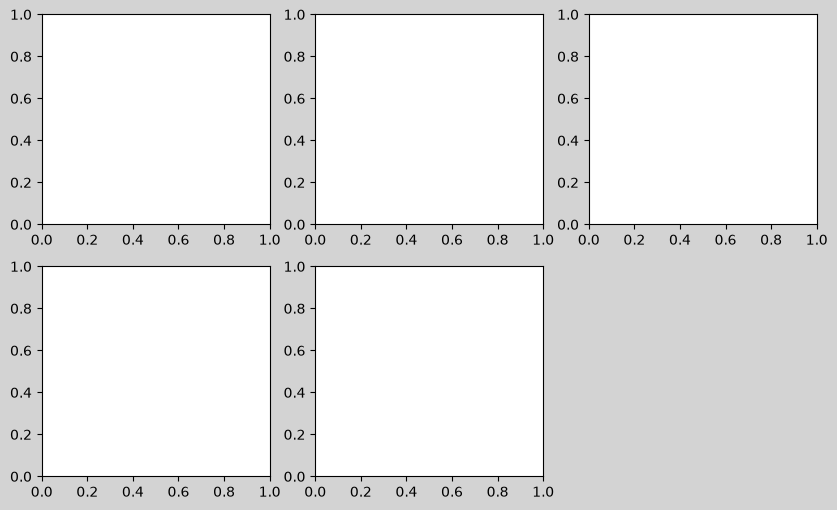

In [4]:
fig = plt.figure(figsize = (10,6), facecolor='lightgrey') # figsize: width, height in inches, facecolor: background color.
ax1 = fig.add_subplot(2, 3, 1) # Can you guess what these numbers mean?
ax2 = fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3)
ax4 = fig.add_subplot(2, 3, 4)
ax5 = fig.add_subplot(2, 3, 5)
plt.show()

#### Standard way of creating a figure and axes

In practice, however, we create a figure and (possibly multiple) axes at the same time by `plt.subplots()`.

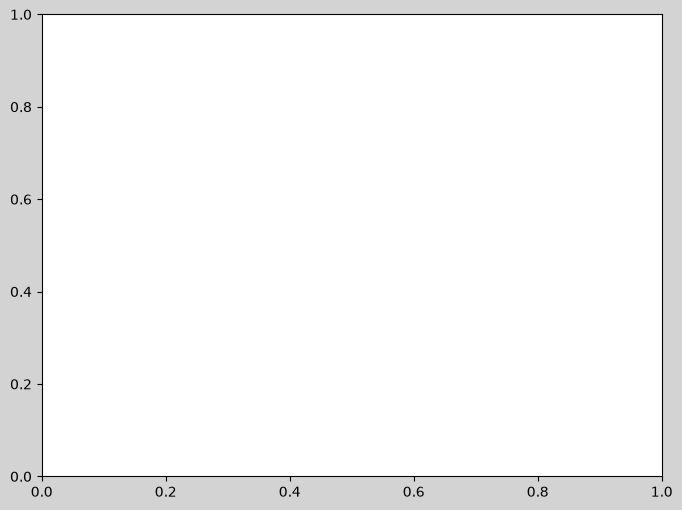

In [5]:
fig, ax = plt.subplots(figsize=(8,6), facecolor='lightgrey')
plt.show()

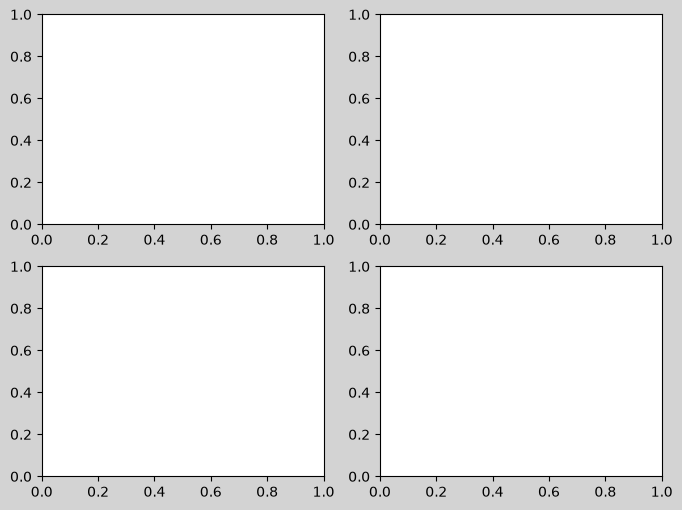

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(8,6), facecolor='lightgrey') 
# plt.subplots(nrows=2, ncols=2, figsize=(8,6), facecolor='lightgrey')
plt.show()

We will discuss more about multiple axes [later](#iv-multiple-axes)!

## II. Graphical elements

#### II.1. Basic Plot Elements (Primary Graph Types)
| Type       | Method                  | Description                           |
| ---------- | ----------------------- | ------------------------------------- |
| Line       | `ax.plot()`             | Line plot                             |
| Scatter    | `ax.scatter()`          | Scatter plot                          |
| Bar        | `ax.bar()`, `ax.barh()` | Vertical / horizontal bar plot        |
| Histogram  | `ax.hist()`             | Histogram                             |
| Boxplot    | `ax.boxplot()`          | Box plot (summary of distribution)    |
| Pie        | `ax.pie()`              | Pie chart                             |
| ...        | ...                     | ...                                   |

Each method has their own set of arguments. Again, you don't have to memorize all of them. It's literally impossible. Go to the official documentation (most reliable), search online, or use AI assistant.

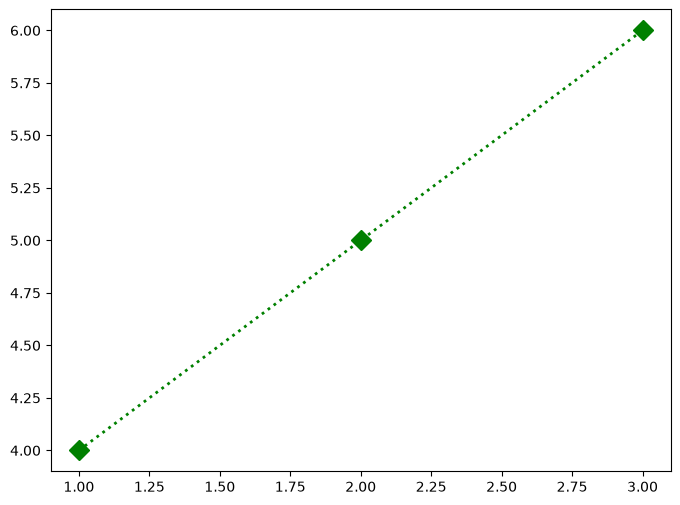

In [7]:
fig, ax = plt.subplots(figsize=(8,6))

ax.plot([1,2,3], [4,5,6], 'D:g', linewidth=2, markersize=10)

plt.show()

> People often skip using `fig, ax = plt.subplots()` when creating a single plot. Instead, they use simpler commands like `plt.plot()`. This works because `matplotlib` automatically creates a `Figure` and an `Axes` object behind the scenes. However, I strongly recommend explicitly using `plt.subplots()` so you can become familiar with object-oriented interface. It offers more control and flexibility, especially when you start working with multiple plots or need to fine-tune your figure layout.

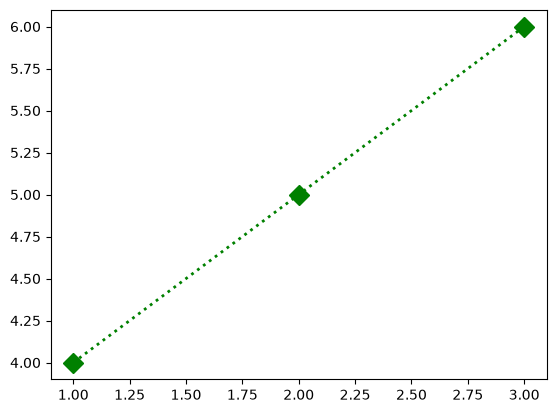

In [8]:
plt.plot([1,2,3], [4,5,6], 'D:g', linewidth=2, markersize=10) # This automatically creates a figure and axes if none exist.
plt.show()

#### II.2. Text and Annotation Elements
| Type       | Method                               | Description                            |
| ---------- | ------------------------------------ | -------------------------------------- |
| Title      | `ax.set_title()`                     | Title for each subplot                 |
| X/Y Labels | `ax.set_xlabel()`, `ax.set_ylabel()` | Labels for x and y axes                |
| Text       | `ax.text(x, y, "text")`              | Place text at any position in the plot |
| Annotate   | `ax.annotate()`                      | Add annotation with optional arrow     |


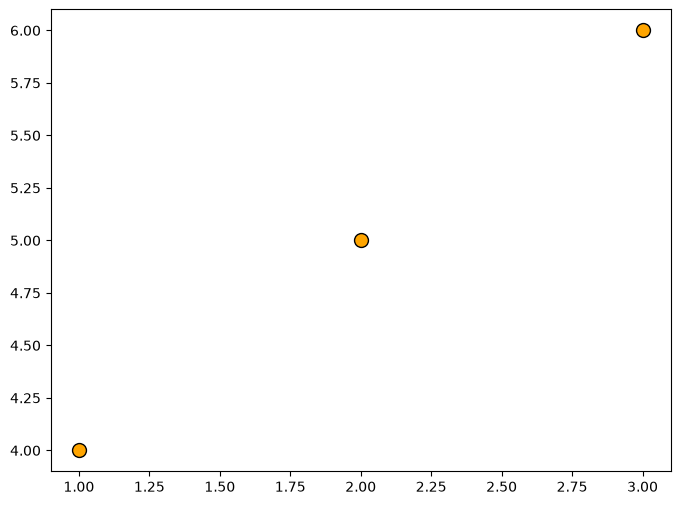

In [9]:
fig, ax = plt.subplots(figsize=(8,6))

ax.scatter([1,2,3], [4,5,6], marker='o', color='orange', s=100, edgecolor='black')

plt.show()

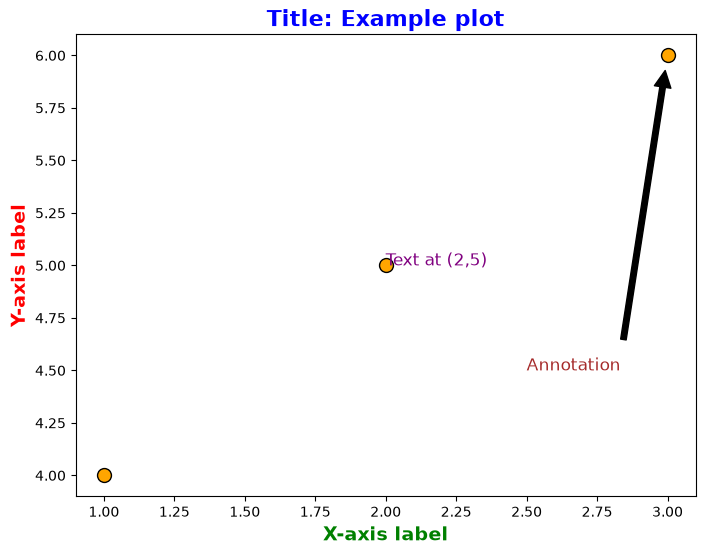

In [10]:
fig, ax = plt.subplots(figsize=(8,6))

ax.scatter([1,2,3], [4,5,6], marker='o', color='orange', s=100, edgecolor='black')

ax.set_title("Title: Example plot", fontsize=16, fontweight='bold', color='blue')
ax.set_xlabel("X-axis label", fontsize=14, fontweight='bold', color='green')
ax.set_ylabel("Y-axis label", fontsize=14, fontweight='bold', color='red')
ax.text(2, 5, "Text at (2,5)", fontsize=12, color='purple')
ax.annotate("Annotation", xy=(3,6), xytext=(2.5,4.5),
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=12, color='brown')

plt.show()

#### II.3. Ticks, Limits, and Grid
| Element     | Method                                         | Description                               |
| ----------- | ---------------------------------------------- | ----------------------------------------- |
| Ticks       | `ax.set_xticks()`, `ax.set_yticks()`           | Specify tick positions                    |
| Tick Labels | `ax.set_xticklabels()`, `ax.set_xticklabels()` | Customize tick labels                     |
| Axis Limits | `ax.set_xlim()`, `ax.set_ylim()`               | Set visible range for x and y axes        |
| Grid        | `ax.grid(True)`                                | Show grid lines                           |


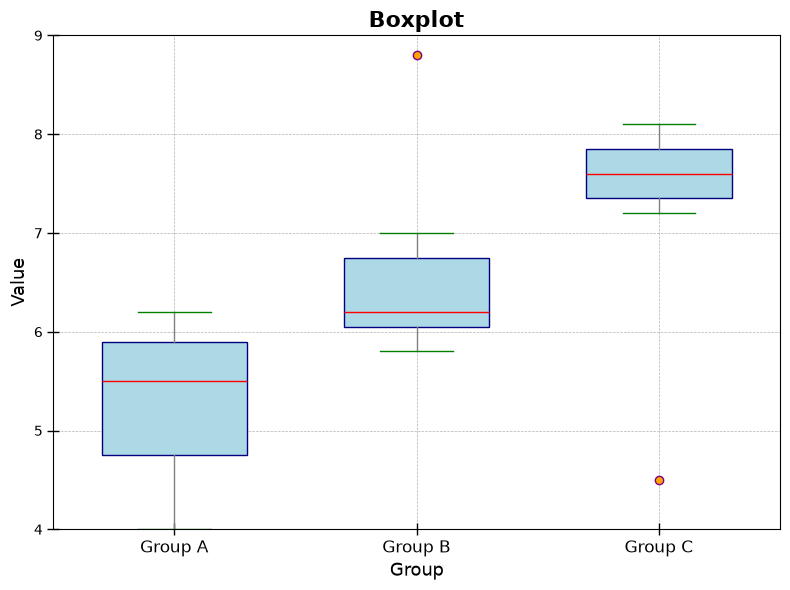

In [11]:
df = pd.DataFrame({
    'Group A': [4, 5, 6, 5.5, 4.5, 6.2, 5.8],
    'Group B': [6, 6.5, 5.8, 6.1, 7, 6.2, 8.8],
    'Group C': [7.5, 4.5, 7.8, 7.9, 7.2, 8.1, 7.6]
})

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot([df['Group A'], df['Group B'], df['Group C']],
           widths=0.6, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red'),
           whiskerprops=dict(color='gray'),
           capprops=dict(color='green'),
           flierprops=dict(marker='o', markersize=6, markerfacecolor='orange', markeredgecolor='purple'))

# --- Ticks & Labels ---
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(df.columns, fontsize=12)
ax.set_yticks([4, 5, 6, 7, 8, 9])
ax.tick_params(axis='both', direction='inout', length=8, width=1, colors='black')

# --- Limits ---
ax.set_xlim(0.5, 3.5)
ax.set_ylim(4, 9)

# --- Grid & Titles ---
ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.6)
ax.set_title('Boxplot', fontsize=16, fontweight='bold')
ax.set_xlabel('Group', fontsize=13)
ax.set_ylabel('Value', fontsize=13)

plt.tight_layout()
plt.show()


#### II.4. Legend
| Method        | Description                                            |
| ------------- | ------------------------------------------------------ |
| `ax.legend()` | Display legend for plotted elements                    |
| `label="..."` | Assign label to each plot element to include in legend |


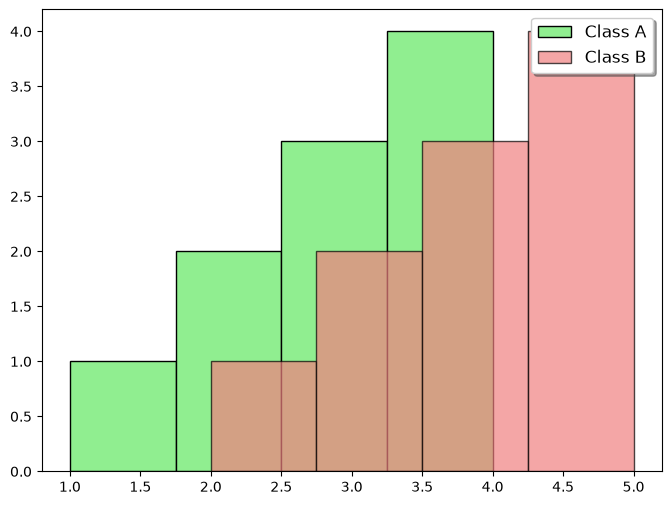

In [12]:
df = pd.DataFrame({
    'Class A': [1, 2, 2, 3, 3, 3, 4, 4, 4, 4],
    'Class B': [2, 3, 3, 4, 4, 4, 5, 5, 5, 5]
})

fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(df['Class A'], bins=4, color='lightgreen', edgecolor='black', label='Class A')
ax.hist(df['Class B'], bins=4, color='lightcoral', edgecolor='black', alpha=0.7, label='Class B') # alpha for transparency

ax.legend(loc='upper right', fontsize=12, shadow=True)
plt.show()

## III. Basic structure of plotting

[Anatomy of a figure](https://matplotlib.org/stable/_images/sphx_glr_anatomy_001_2_00x.png)

Sample code
```python
# data prep
data = ...

# create a fig and ax
fig, ax = plt.subplots(...)

# plot
ax.DESIRED_PLOT(...)
...

# customize (you don't have to modify every detail)
ax.set_xlabel(...)
ax.set_ylabel(...)
ax.set_title(...)
ax.set_xticks(...)
ax.set_xticklabels(...)
ax.set_yticks(...)
ax.set_yticklabels(...)
ax.legend(...)
...

# render
plt.tight_layout()
plt.show()
```

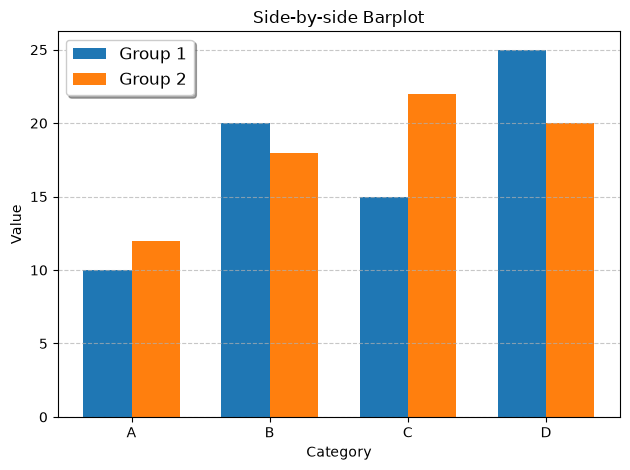

In [13]:
import numpy as np

# data
labels = ['A', 'B', 'C', 'D']
group1 = [10, 20, 15, 25]
group2 = [12, 18, 22, 20]

x = np.arange(len(labels))
width = 0.35

# fig and ax
fig, ax = plt.subplots()

# draw bars
ax.bar(x - width/2, group1, width, label='Group 1')
ax.bar(x + width/2, group2, width, label='Group 2')

# Customize the plot
ax.set_xlabel('Category')
ax.set_ylabel('Value')
ax.set_title('Side-by-side Barplot')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='upper left', fontsize=12, shadow=True)

# render the plot
plt.tight_layout()
plt.show()

## IV. Multiple Axes

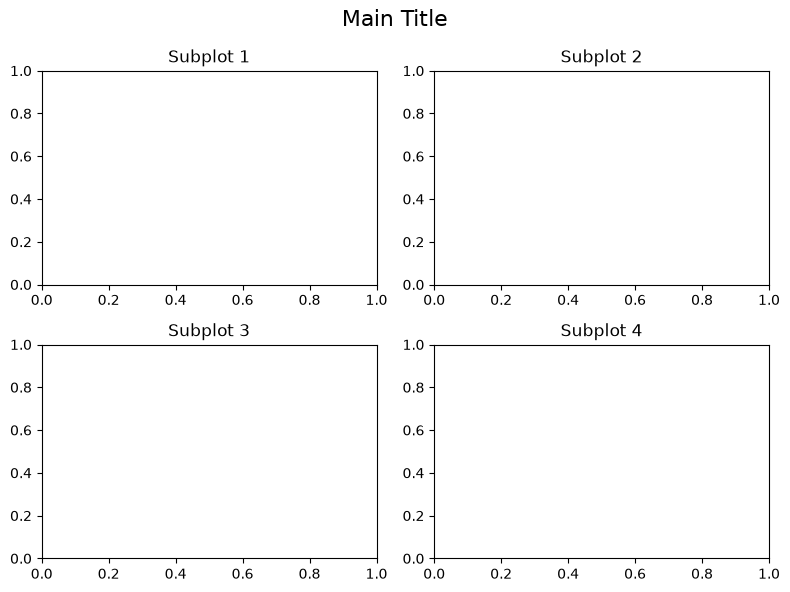

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(8,6))
fig.suptitle("Main Title", fontsize=16)

axes[0,0].set_title("Subplot 1")
axes[0,1].set_title("Subplot 2")
axes[1,0].set_title("Subplot 3")
axes[1,1].set_title("Subplot 4")

plt.tight_layout()
plt.show()

In [ ]:
# shared x and y axes
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(8,6))
fig.suptitle("Main Title", fontsize=16)

axes[0,0].set_title("Subplot 1")
axes[0,1].set_title("Subplot 2")
axes[1,0].set_title("Subplot 3")
axes[1,1].set_title("Subplot 4")

plt.tight_layout()
plt.show()

In [ ]:
df = pd.DataFrame({
    'Year': [2019, 2020, 2021, 2022],
    'Sales_A': [120, 135, 150, 160],
    'Sales_B': [80, 95, 100, 120],
    'Profit_A': [30, 32, 36, 38],
    'Profit_B': [18, 20, 22, 26]
})

fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
fig.suptitle("Company Performance (2019–2022)", fontsize=16, fontweight='bold')

# [0, 0] Sales of A
axs[0, 0].bar(df['Year'], df['Sales_A'], color='steelblue')
axs[0, 0].set_title("Sales - Product A")

# [0, 1] Sales of B
axs[0, 1].bar(df['Year'], df['Sales_B'], color='salmon')
axs[0, 1].set_title("Sales - Product B")

# [1, 0] Profit of A
axs[1, 0].plot(df['Year'], df['Profit_A'], color='seagreen', marker='o')
axs[1, 0].set_title("Profit - Product A")

# [1, 1] Profit of B
axs[1, 1].plot(df['Year'], df['Profit_B'], color='orange', marker='o')
axs[1, 1].set_title("Profit - Product B")


for ax in axs[1, :]:
    ax.set_xticks(df['Year'])
    ax.set_xticklabels(df['Year'])

for ax in axs[:, 0]:   
    ax.set_ylabel("Amount (k$)")

plt.tight_layout()
plt.show()

## V. $\LaTeX$
You can also include math expressions by using `r$MATH_EXPRESSION$`

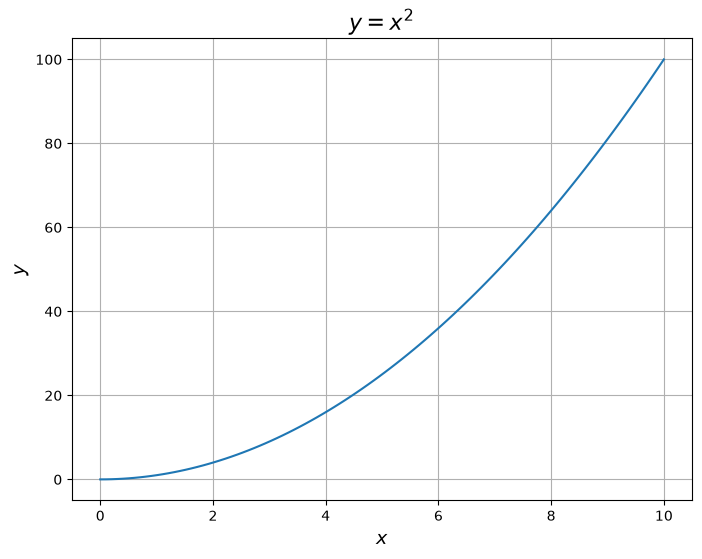

In [15]:
x = np.linspace(0, 10, 100)
y = x**2

fig, ax = plt.subplots(figsize=(8,6))

ax.plot(x, y)

ax.set_title(r'$y = x^2$', fontsize=16)
ax.set_xlabel(r'$x$', fontsize=14)
ax.set_ylabel(r'$y$', fontsize=14)
plt.grid()

plt.show()

## VI. Save

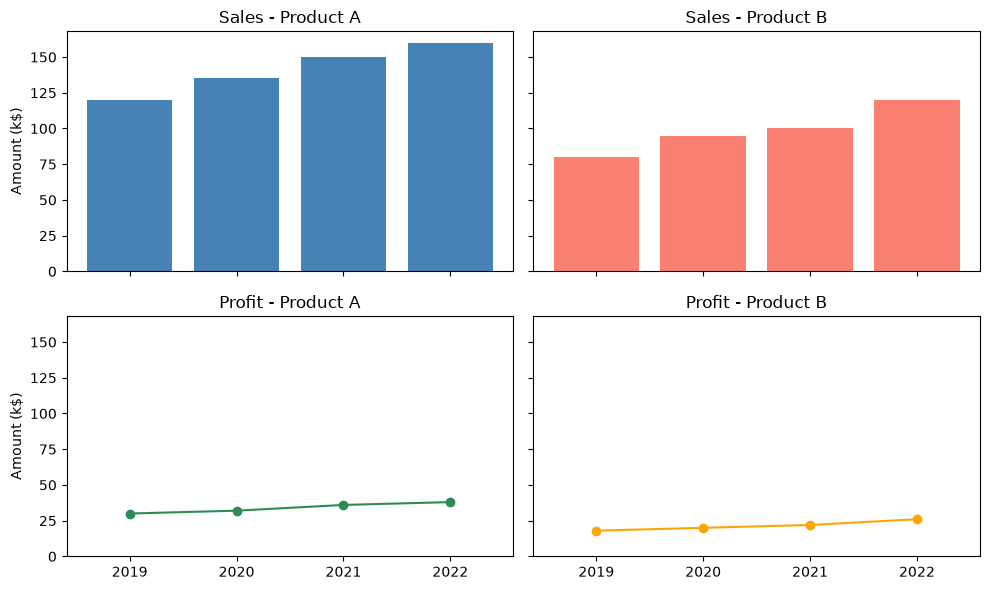

In [16]:
df = pd.DataFrame({
    'Year': [2019, 2020, 2021, 2022],
    'Sales_A': [120, 135, 150, 160],
    'Sales_B': [80, 95, 100, 120],
    'Profit_A': [30, 32, 36, 38],
    'Profit_B': [18, 20, 22, 26]
})

fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)

# [0, 0] Sales of A
axs[0, 0].bar(df['Year'], df['Sales_A'], color='steelblue')
axs[0, 0].set_title("Sales - Product A")

# [0, 1] Sales of B
axs[0, 1].bar(df['Year'], df['Sales_B'], color='salmon')
axs[0, 1].set_title("Sales - Product B")

# [1, 0] Profit of A
axs[1, 0].plot(df['Year'], df['Profit_A'], color='seagreen', marker='o')
axs[1, 0].set_title("Profit - Product A")

# [1, 1] Profit of B
axs[1, 1].plot(df['Year'], df['Profit_B'], color='orange', marker='o')
axs[1, 1].set_title("Profit - Product B")


for ax in axs[1, :]:
    ax.set_xticks(df['Year'])
    ax.set_xticklabels(df['Year'])

for ax in axs[:, 0]:   
    ax.set_ylabel("Amount (k$)")

plt.tight_layout()
plt.show()

In [ ]:
# save only w svg!
fig.savefig("example.svg") # Save as SVG. High quality vector graphic format, suitable for publications and presentations.
fig.savefig("example.png") # Save as PNG.